**Retail Demand Forecasting**

**Phase 5 – Statistical Analysis**

**Business Objective**

Validate business hypotheses using statistical tests and quantify relationships between variables influencing retail sales.

In [1]:
import pandas as pd
import numpy as np

import scipy.stats as stats

from scipy.stats import shapiro
from scipy.stats import ttest_ind
from scipy.stats import chi2_contingency
from scipy.stats import f_oneway

import matplotlib.pyplot as plt
import seaborn as sns

from statsmodels.stats.outliers_influence import variance_inflation_factor

In [2]:
df = pd.read_csv("../data/processed/cleaned_data.csv")

df["Date"] = pd.to_datetime(df["Date"])

C:\Users\mahip\AppData\Local\Temp\ipykernel_5340\1326193246.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/cleaned_data.csv")


In [3]:
df = pd.read_csv("../data/processed/cleaned_data.csv", nrows=5)

print(df.columns)

Index(['Store', 'DayOfWeek', 'Date', 'Sales', 'Customers', 'Open', 'Promo',
       'StateHoliday', 'SchoolHoliday', 'StoreType', 'Assortment',
       'CompetitionDistance', 'CompetitionOpenSinceMonth',
       'CompetitionOpenSinceYear', 'Promo2', 'Promo2SinceWeek',
       'Promo2SinceYear', 'PromoInterval'],
      dtype='object')


In [4]:
print(df["StateHoliday"].unique())


[0]


In [5]:
df = pd.read_csv(
    "../data/processed/cleaned_data.csv",
    dtype={"StateHoliday": str},
    low_memory=False
)

In [6]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Store,1017209.0,558.429727,321.908651,1.0,280.0,558.0,838.0,1115.0
DayOfWeek,1017209.0,3.998341,1.997391,1.0,2.0,4.0,6.0,7.0
Sales,1017209.0,5773.818972,3849.926175,0.0,3727.0,5744.0,7856.0,41551.0
Customers,1017209.0,633.145946,464.411734,0.0,405.0,609.0,837.0,7388.0
Open,1017209.0,0.830107,0.375539,0.0,1.0,1.0,1.0,1.0
Promo,1017209.0,0.381515,0.485759,0.0,0.0,0.0,1.0,1.0
SchoolHoliday,1017209.0,0.178647,0.383056,0.0,0.0,0.0,0.0,1.0
CompetitionDistance,1017209.0,5422.033790,7706.913044,20.0,710.0,2330.0,6880.0,75860.0
CompetitionOpenSinceMonth,1017209.0,4.926878,4.283543,0.0,0.0,4.0,9.0,12.0
CompetitionOpenSinceYear,1017209.0,1370.172511,935.363448,0.0,0.0,2006.0,2011.0,2015.0


**BUSINESS HYPOTHESIS 1**
Question

Are sales normally distributed?

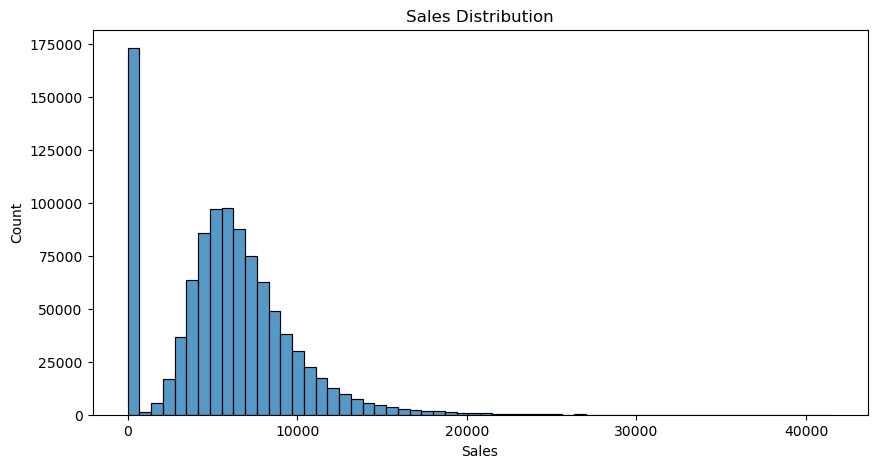

In [9]:
plt.figure(figsize=(10,5))

sns.histplot(df["Sales"], bins=60)

plt.title("Sales Distribution")

plt.show()


**Q-Q Plot**

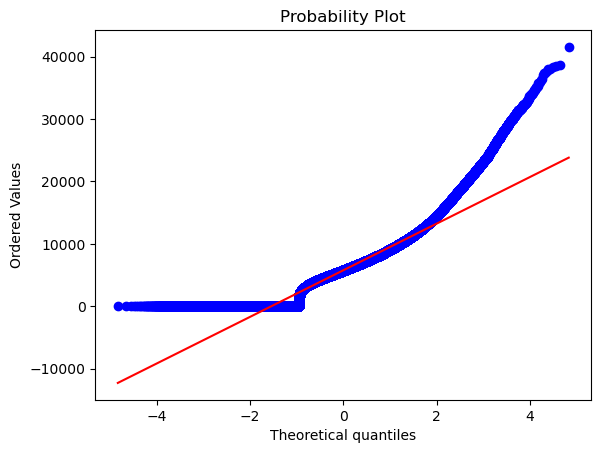

In [8]:
import scipy.stats as stats

stats.probplot(df["Sales"], dist="norm", plot=plt)

plt.show()

**Shapiro-Wilk Test**

In [11]:
sample = df["Sales"].sample(5000, random_state=42)

stat, p = shapiro(sample)

print(stat)
print(p)

0.945490065641878
1.50869483278407e-39


**The value of p is very very less than the 0.05 hence the sales are not normally distributed**

**BUSINESS HYPOTHESIS 2**
Question

Do promotions significantly increase sales?

In [12]:
promo = df[df["Promo"] == 1]["Sales"]

no_promo = df[df["Promo"] == 0]["Sales"]

Independent T test

In [13]:
t_stat, p = ttest_ind(
    promo,
    no_promo,
    equal_var=False
)

print(t_stat)
print(p)

512.3755316936371
0.0


hence the value of p<0.05 hence promo impacts the sales

**BUSINESS HYPOTHESIS 3**
Question

Does Store Type affect Sales?

In [14]:
a = df[df["StoreType"]=="a"]["Sales"]

b = df[df["StoreType"]=="b"]["Sales"]

c = df[df["StoreType"]=="c"]["Sales"]

d = df[df["StoreType"]=="d"]["Sales"]

ANOVA

In [15]:
f,p = f_oneway(a,b,c,d)

print(f)

print(p)

6817.192011836288
0.0


th value of p is less than 0.05 .Store types have significantly different sales.

**BUSINESS HYPOTHESIS 4**
Question

Are Customers correlated with Sales?

Pearson Correlation

In [17]:
corr,p = stats.pearsonr(
    df["Customers"],
    df["Sales"]
)

print(corr)

print(p)

0.8947107733017016
0.0


the corelation is close to 1 ,hence there is strong relation between customers and sales

**BUSINESS HYPOTHESIS 5**
Question

Does Competition Distance correlate with Sales?

In [18]:
corr,p = stats.pearsonr(
    df["CompetitionDistance"],
    df["Sales"]
)

print(corr)

print(p)

-0.01886982841915687
9.059839675886547e-81


no the value of corr is not close to 1 hence it does not have any correlation between competition distance and sales

**BUSINESS HYPOTHESIS 6**
Question

Is Promotion associated with State Holiday?

In [19]:
table = pd.crosstab(
    df["Promo"],
    df["StateHoliday"]
)

table

StateHoliday,0,a,b,c
Promo,,,,
0,608875,12809,3345,4100
1,377284,7451,3345,0


In [20]:
chi2,p,dof,expected = chi2_contingency(table)

print(chi2)

print(p)

2948.087398538137
0.0


hence the value of p is less than 0.05 than it has a relation between promo and stateholiday


**BUSINESS HYPOTHESIS 7**
Question

Is multicollinearity present?

In [21]:
num = df.select_dtypes(
    include=np.number
)

num.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
0,1,5,5263,555,1,1,1,1270.0,9.0,2008.0,0,0.0,0.0
1,2,5,6064,625,1,1,1,570.0,11.0,2007.0,1,13.0,2010.0
2,3,5,8314,821,1,1,1,14130.0,12.0,2006.0,1,14.0,2011.0
3,4,5,13995,1498,1,1,1,620.0,9.0,2009.0,0,0.0,0.0
4,5,5,4822,559,1,1,1,29910.0,4.0,2015.0,0,0.0,0.0


In [22]:
X = num.drop(columns=["Sales"])

In [23]:
vif = pd.DataFrame()

vif["Feature"] = X.columns

vif["VIF"] = [
    variance_inflation_factor(
        X.values,
        i
    )
    for i in range(X.shape[1])
]

vif

,Feature,VIF
0,Store,3.617650e+00
1,DayOfWeek,3.516025e+00
2,Customers,5.080090e+00
3,Open,8.311850e+00
4,Promo,1.894899e+00
5,SchoolHoliday,1.227888e+00
6,CompetitionDistance,1.533777e+00
7,CompetitionOpenSinceMonth,6.093562e+00
8,CompetitionOpenSinceYear,8.031722e+00
9,Promo2,1.568963e+06


**Variance Inflation Factor (VIF) Analysis*

The Variance Inflation Factor (VIF) was calculated to detect multicollinearity among the numerical features.

- Most features have VIF values below 5, indicating acceptable levels of multicollinearity.
- **Customers**, **Open**, **CompetitionOpenSinceMonth**, and **CompetitionOpenSinceYear** exhibit relatively high VIF values, suggesting moderate to high correlation with other predictors.
- **Promo2** and **Promo2SinceYear** have extremely high VIF values (>1,000,000), indicating severe multicollinearity. This is expected because these variables are closely related and encode similar information.
- To improve model stability and interpretability, one of the highly correlated features can be removed or transformed through feature engineering before model training.

**BUSINESS HYPOTHESIS 8**
Question

Confidence interval for average sales.

In [26]:
mean = df["Sales"].mean()

std = df["Sales"].std()

n = len(df)

In [27]:
margin = 1.96 * (std / np.sqrt(n))

lower = mean - margin

upper = mean + margin

print(lower, upper)

5766.337219140197 5781.300725470989


**BUSINESS HYPOTHESIS 9**
Question

Identify extreme outliers.

In [28]:
Q1 = df["Sales"].quantile(.25)

Q3 = df["Sales"].quantile(.75)

IQR = Q3 - Q1

In [29]:
lower = Q1 - 1.5*IQR

upper = Q3 + 1.5*IQR

outliers = df[
    (df["Sales"]<lower)|
    (df["Sales"]>upper)
]

outliers.shape

(26694, 18)

**Findings from this analysis**

- *the sales are not normally distributed*
-*promo impacts the sales*
- *Store types have significantly different sales.*
- *there is strong relation between customers and sales.*
- *it does not have any correlation between competition distance and sales.*
- *it has a relation between promo and stateholiday.*
- *Customers, Open, CompetitionOpenSinceMonth, and CompetitionOpenSinceYear exhibit relatively high VIF values, suggesting moderate to high correlation with other predictors.*
- *Promo2 and Promo2SinceYear have extremely high VIF values (>1,000,000), indicating severe multicollinearity. This is expected because these variables are closely related and encode similar information.*